# 02 · Weight Initialisation: how to pick the starting weights
NumPy for the model · matplotlib for graphs · Runs on Google Colab

Data: handwritten digits (64 inputs). Network: many hidden layers of 64 neurons.

1. The problem: deep networks from ±1 starting weights
2. Simple example: why the spread grows with the number of inputs
3. Why not start every weight at the same value?
4. The fix: Xavier and He
5. Train the 6-layer network again
6. Experiments

## Setup: data and the same functions as the previous notebook, with a choice of starting weights

In [1]:
import io, urllib.request
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
np.set_printoptions(precision=3, suppress=True)
np.seterr(all="ignore")                                           # exploding networks overflow; we measure that instead

ACT = {
    "sigmoid": (lambda s: 1 / (1 + np.exp(-s)), lambda s: np.exp(-s) / (1 + np.exp(-s)) ** 2),
    "tanh":    (np.tanh,                         lambda s: 1 - np.tanh(s) ** 2),
    "relu":    (lambda s: np.maximum(0, s),      lambda s: np.where(s > 0, 1.0, 0.0)),
}

def add_x0(X):
    return np.hstack([-np.ones((len(X), 1)), X])

def load_digits(name):
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/optdigits/" + name
    d = np.genfromtxt(io.StringIO(urllib.request.urlopen(url).read().decode()), delimiter=",").astype(int)
    return d[:, :64] / 16, d[:, 64]

Xtr, ytr = load_digits("optdigits.tra")
Xte, yte = load_digits("optdigits.tes")
Xtr0, Ytr = add_x0(Xtr), np.eye(10)[ytr]
print(f"train {Xtr.shape}, test {Xte.shape}")

train (3823, 64), test (1797, 64)


| `init` | Starting weights for a layer with $n_{in}$ inputs |
|---|---|
| `"uniform"` | random in $[-\text{scale}, +\text{scale}]$ (what we used so far, scale 1) |
| `"constant"` | every weight = scale |
| `"xavier"` | normal, spread $\sqrt{1 / n_{in}}$ × scale |
| `"he"` | normal, spread $\sqrt{2 / n_{in}}$ × scale |

In [2]:
def new_net(sizes, act="tanh", init="xavier", scale=1.0):
    W = []
    for n_in, n_out in zip(sizes[:-1], sizes[1:]):
        shape = (n_in + 1, n_out)
        if init == "uniform":
            W.append(rng.uniform(-scale, scale, shape))
        elif init == "constant":
            W.append(np.full(shape, scale))
        elif init == "xavier":
            W.append(rng.normal(0, scale * np.sqrt(1 / n_in), shape))
        else:                                                     # "he"
            W.append(rng.normal(0, scale * np.sqrt(2 / n_in), shape))
    return {"act": act, "W": W}

def softmax(s):
    e = np.exp(s - s.max())
    return e / e.sum()

def forward_pass(x, net):
    f = ACT[net["act"]][0]
    h, cache = x, []
    for W in net["W"][:-1]:
        s = h @ W
        cache.append((h, s))
        h = np.r_[-1, f(s)]
    cache.append((h, None))
    return softmax(h @ net["W"][-1]), cache

def compute_error(y, p):
    return y - p

def backward_pass(net, error, cache, lr):
    df = ACT[net["act"]][1]
    delta, new_W, deltas = error, list(net["W"]), []
    for l in range(len(net["W"]) - 1, -1, -1):
        deltas.insert(0, delta)
        dW = -np.outer(cache[l][0], delta)
        if l > 0:
            delta = (net["W"][l][1:] @ delta) * df(cache[l - 1][1])
        new_W[l] = net["W"][l] - lr * dW
    return {"act": net["act"], "W": new_W}, deltas

def layer_sums(P0, net):
    # s at every hidden layer for many points at once (forward only)
    f = ACT[net["act"]][0]
    H, sums = P0, []
    for W in net["W"][:-1]:
        sums.append(H @ W)
        H = add_x0(f(sums[-1]))
    return sums, H @ net["W"][-1]

def test_acc(net):
    return 100 * (np.argmax(layer_sums(add_x0(Xte), net)[1], axis=1) == yte).mean()

def train(net, lr, epochs):
    accs = []
    for _ in range(epochs):
        for i in rng.permutation(len(Xtr0)):
            p, cache = forward_pass(Xtr0[i], net)
            net, _ = backward_pass(net, compute_error(Ytr[i], p), cache, lr)
        accs.append(test_acc(net))
    return net, accs

deep_sizes = [64] + [64] * 6 + [10]

---
# Part 1: the problem — 6 hidden layers from ±1 starting weights
Spread (standard deviation) of $s$ at each hidden layer, then 3 epochs of training.

In [3]:
for act in ["tanh", "relu"]:
    net = new_net(deep_sizes, act, "uniform", 1.0)
    sums, _ = layer_sums(Xtr0, net)
    trained, _ = train(net, 0.01, 3)
    print(f"{act:>5}, ±1: spread of s at layers 1..6 = {np.array([S.std() for S in sums])} -> test accuracy {test_acc(trained):.1f}%")

 tanh, ±1: spread of s at layers 1..6 = [2.203 3.77  4.178 4.224 4.164 4.223] -> test accuracy 72.5%
 relu, ±1: spread of s at layers 1..6 = [  2.593   7.731  27.866  78.23  200.199 594.322] -> test accuracy 9.9%


tanh: $s$ spreads to about 4, deep in tanh's flat ends (slope ≈ 0). ReLU: the spread **explodes** layer after layer. 10% = guessing.

---
# Part 2: simple example — why the spread grows

One neuron with $n$ inputs: $s = x_1 w_1 + \dots + x_n w_n$. Adding $n$ random terms makes $s$ spread more:
$$\text{spread}(s) \approx \sqrt{n} \times \text{spread}(w) \times \text{spread}(x)$$

In [4]:
for n in [1, 4, 16, 64]:
    x = rng.normal(0, 1, (10000, n))                               # 10,000 random inputs, spread 1
    w = rng.uniform(-1, 1, (n, 10000))                             # weights in ±1, spread 1/√3 ≈ 0.577
    s = np.einsum("ij,ji->i", x, w)
    print(f"n = {n:>2} inputs: measured spread of s = {s.std():.3f} | √n × 0.577 × 1 = {np.sqrt(n) * 0.577:.3f}")

n =  1 inputs: measured spread of s = 0.569 | √n × 0.577 × 1 = 0.577
n =  4 inputs: measured spread of s = 1.178 | √n × 0.577 × 1 = 1.154
n = 16 inputs: measured spread of s = 2.300 | √n × 0.577 × 1 = 2.308
n = 64 inputs: measured spread of s = 4.584 | √n × 0.577 × 1 = 4.616


With 64 inputs and weights ±1, $s$ spreads to about 4.6. **To keep the spread near 1, the weight spread must shrink as $n$ grows: spread($w$) = $\sqrt{1/n}$.**

## Histograms of $s$ at each layer (tanh): too small, too big, just right

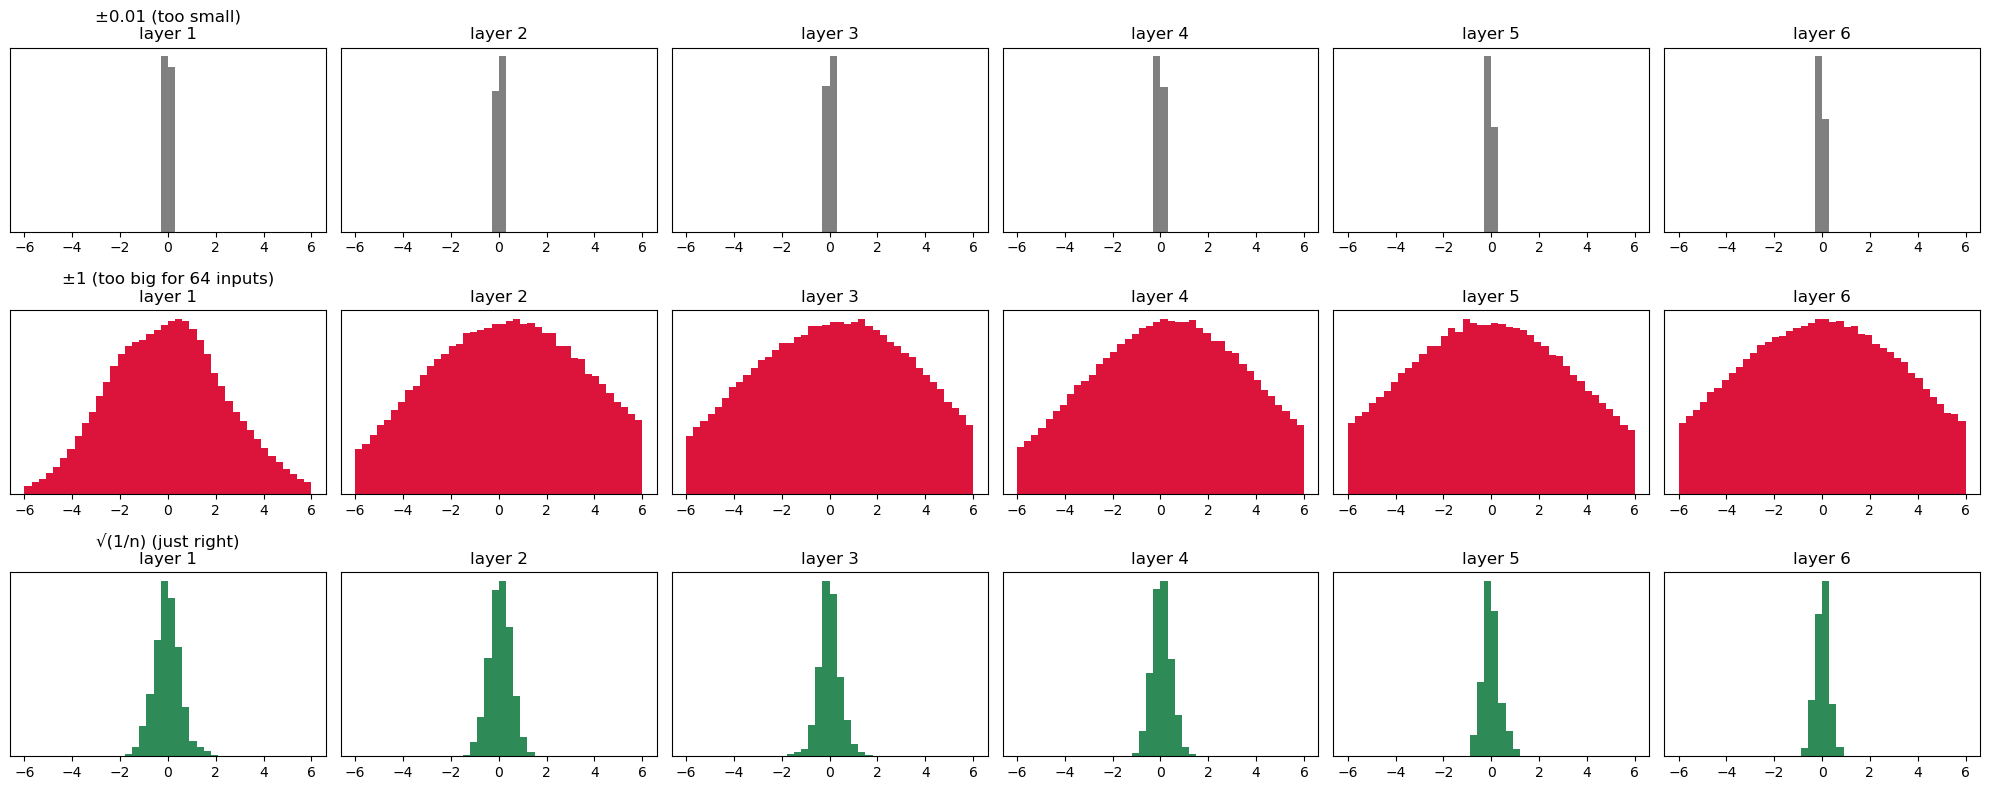

In [5]:
cases = [("±0.01 (too small)", new_net(deep_sizes, "tanh", "uniform", 0.01)),
         ("±1 (too big for 64 inputs)", new_net(deep_sizes, "tanh", "uniform", 1.0)),
         ("√(1/n) (just right)", new_net(deep_sizes, "tanh", "xavier"))]
fig, axes = plt.subplots(3, 6, figsize=(20, 8))
for row, (name, net) in enumerate(cases):
    for l, S in enumerate(layer_sums(Xtr0, net)[0]):
        axes[row, l].hist(S.ravel(), bins=40, range=(-6, 6), color=["gray", "crimson", "seagreen"][row])
        axes[row, l].set(title=f"{name}\nlayer {l + 1}" if l == 0 else f"layer {l + 1}", yticks=[])
plt.tight_layout()
plt.show()

---
# Part 3: why not start every weight at the same value?
Network `[64, 4, 10]`, every weight = 0.1: every hidden neuron computes the same thing, gets the same δ, makes the same update.

In [6]:
same, _ = train(new_net([64, 4, 10], "tanh", "constant", 0.1), 0.01, 1)
print("First 5 rows of the hidden weights after training (one column per neuron):\n", same["W"][0][:5])
print(f"\nAll 4 hidden neurons identical? {np.allclose(same['W'][0], same['W'][0][:, :1])}")
print(f"Test accuracy: {test_acc(same):.1f}%  (4 identical neurons = 1 neuron)")

random_start, _ = train(new_net([64, 4, 10], "tanh", "xavier"), 0.01, 1)
print(f"\nSame network from random starting weights: test accuracy {test_acc(random_start):.1f}%")

First 5 rows of the hidden weights after training (one column per neuron):
 [[0.118 0.118 0.118 0.118]
 [0.1   0.1   0.1   0.1  ]
 [0.1   0.1   0.1   0.1  ]
 [0.093 0.093 0.093 0.093]
 [0.087 0.087 0.087 0.087]]

All 4 hidden neurons identical? True
Test accuracy: 9.9%  (4 identical neurons = 1 neuron)

Same network from random starting weights: test accuracy 78.0%


Starting weights must be **random**, so the neurons start different and learn different things.

---
# Part 4: the fix — pick the spread from the number of inputs

| Name | For | Spread of starting weights |
|---|---|---|
| **Xavier / Glorot** | sigmoid, tanh | $\sqrt{1 / n_{in}}$ |
| **He** | ReLU | $\sqrt{2 / n_{in}}$ (ReLU zeroes about half its inputs, so double it) |

In [7]:
print(f"{'activation + start':>18} | spread of s at layers 1 ... 6")
print("-" * 75)
for act, init in [("tanh", "uniform"), ("tanh", "xavier"), ("relu", "uniform"), ("relu", "he")]:
    sums, _ = layer_sums(Xtr0, new_net(deep_sizes, act, init))
    print(f"{act + ' + ' + init:>18} | {np.array([S.std() for S in sums])}")

activation + start | spread of s at layers 1 ... 6
---------------------------------------------------------------------------
    tanh + uniform | [2.487 4.021 4.165 4.274 4.401 4.056]
     tanh + xavier | [0.47  0.408 0.374 0.339 0.356 0.364]
    relu + uniform | [  2.45    8.657  28.014 101.905 248.123 934.273]
         relu + he | [0.695 0.709 0.701 0.687 0.693 0.637]


---
# Part 5: train the 6-layer network again (5 epochs)

        tanh, ±1: test accuracy after each epoch [44.5 44.2 62.3 60.8 60.7]
    tanh, Xavier: test accuracy after each epoch [91.4 90.8 92.1 95.  94.8]
        relu, ±1: test accuracy after each epoch [9.9 9.9 9.9 9.9 9.9]
        relu, He: test accuracy after each epoch [87.3 93.4 92.4 93.3 94.8]
 sigmoid, Xavier: test accuracy after each epoch [10.1 10.  10.1  9.7 10.1]


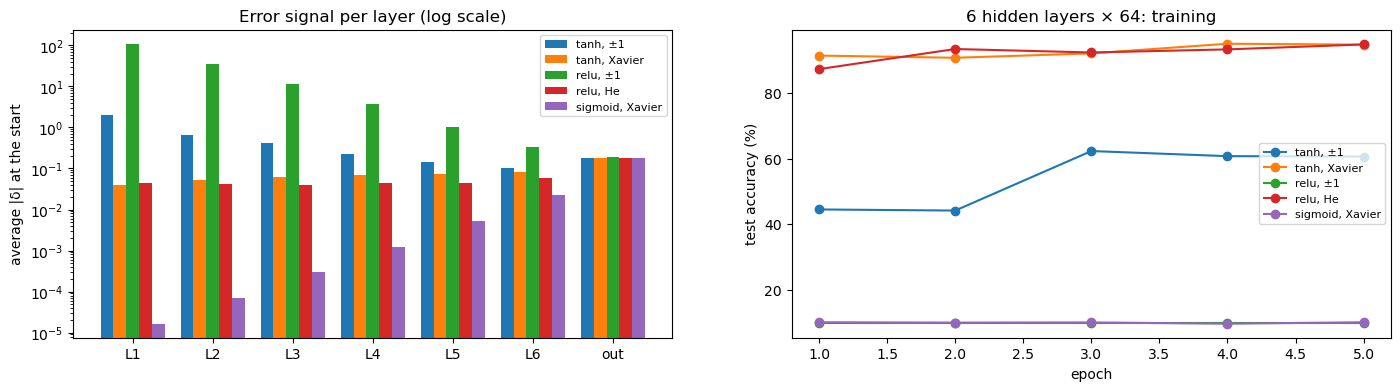

In [8]:
def average_deltas(net, n=500):
    total = np.zeros(len(net["W"]))
    for x, t in zip(Xtr0[:n], Ytr[:n]):
        p, cache = forward_pass(x, net)
        _, deltas = backward_pass(net, compute_error(t, p), cache, 0.0)
        total += [np.abs(d).mean() for d in deltas]
    return total / n

setups = [("tanh, ±1", "tanh", "uniform"), ("tanh, Xavier", "tanh", "xavier"),
          ("relu, ±1", "relu", "uniform"), ("relu, He", "relu", "he"), ("sigmoid, Xavier", "sigmoid", "xavier")]
fig, axes = plt.subplots(1, 2, figsize=(17, 4))
for k, (name, act, init) in enumerate(setups):
    start = new_net(deep_sizes, act, init)
    axes[0].bar(np.arange(1, 8) + (k - 2) * 0.16, average_deltas(start), width=0.16, label=name)
    net, accs = train(start, 0.01, 5)
    print(f"{name:>16}: test accuracy after each epoch {np.round(accs, 1)}")
    axes[1].plot(range(1, 6), accs, "o-", label=name)
axes[0].set(yscale="log", xticks=range(1, 8), xticklabels=[f"L{i}" for i in range(1, 7)] + ["out"],
            ylabel="average |δ| at the start", title="Error signal per layer (log scale)")
axes[1].set(xlabel="epoch", ylabel="test accuracy (%)", title="6 hidden layers × 64: training")
axes[0].legend(fontsize=8)
axes[1].legend(fontsize=8)
plt.show()

Xavier/He keep both the forward signal and δ at a steady size, so all layers learn. Sigmoid's slope (max 0.25) still shrinks δ layer by layer: initialisation alone can't fix deep sigmoid networks.

---
# Part 6: Experiments
## 1. Depth sweep: when does the starting weight matter? (tanh, 3 epochs)

 2 hidden layers: ±1  91.3% | Xavier  94.5%
 4 hidden layers: ±1  89.5% | Xavier  94.2%
 6 hidden layers: ±1  66.4% | Xavier  94.3%
 8 hidden layers: ±1  19.2% | Xavier  93.3%
10 hidden layers: ±1  10.1% | Xavier  88.6%


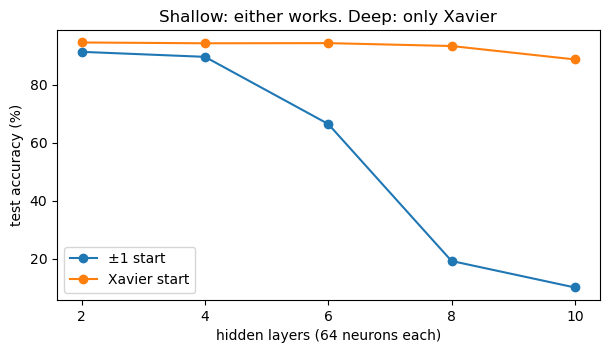

In [9]:
depths = [2, 4, 6, 8, 10]
results = {"uniform": [], "xavier": []}
for d in depths:
    for init in results:
        net, _ = train(new_net([64] + [64] * d + [10], "tanh", init), 0.01, 3)
        results[init].append(test_acc(net))
    print(f"{d:>2} hidden layers: ±1 {results['uniform'][-1]:5.1f}% | Xavier {results['xavier'][-1]:5.1f}%")

fig, ax = plt.subplots(figsize=(7, 3.5))
for init, label in [("uniform", "±1 start"), ("xavier", "Xavier start")]:
    ax.plot(depths, results[init], "o-", label=label)
ax.set(xticks=depths, xlabel="hidden layers (64 neurons each)", ylabel="test accuracy (%)", title="Shallow: either works. Deep: only Xavier")
ax.legend()
plt.show()

## 2. Scale sweep: Xavier spread × 0.1 … 10 (6 hidden layers, tanh, 3 epochs)

Xavier × 0.1 : test accuracy  10.0%
Xavier × 0.3 : test accuracy  10.1%
Xavier × 1   : test accuracy  94.4%
Xavier × 3   : test accuracy  90.7%
Xavier × 10  : test accuracy  10.0%


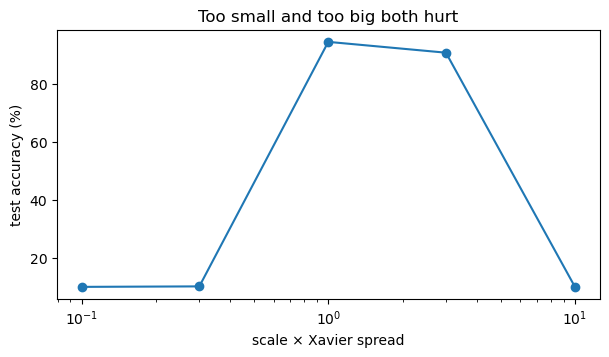

In [10]:
scales = [0.1, 0.3, 1, 3, 10]
accs = []
for scale in scales:
    net, _ = train(new_net(deep_sizes, "tanh", "xavier", scale), 0.01, 3)
    accs.append(test_acc(net))
    print(f"Xavier × {scale:<4}: test accuracy {accs[-1]:5.1f}%")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(scales, accs, "o-")
ax.set(xscale="log", xlabel="scale × Xavier spread", ylabel="test accuracy (%)", title="Too small and too big both hurt")
plt.show()

## 3. Reliability: 3 random starts each (6 hidden layers, tanh, 3 epochs)

In [11]:
for init in ["uniform", "xavier"]:
    runs = [test_acc(train(new_net(deep_sizes, "tanh", init), 0.01, 3)[0]) for _ in range(3)]
    print(f"{init:>8}: test accuracies {np.round(runs, 1)} | mean {np.mean(runs):.1f}%")

 uniform: test accuracies [82.6 70.9 76.1] | mean 76.5%
  xavier: test accuracies [93.3 94.7 93.4] | mean 93.8%


In [ ]:
Next notebook: **mini-batch training** — SGD vs batch vs mini-batch.